## Setup

Run this notebook from a local clone of the [svm-gmu](https://github.com/SushrutGaikwad/svm-gmu) repository. From the repo root, install the project and launch Jupyter with [uv](https://docs.astral.sh/uv/):

```bash
uv sync
uv run jupyter lab
```

The next cell puts the repo's `src/` and `experiments/` folders on the import path, so `svm_gmu` and the shared `_common` helper import from your local clone. Figures are rendered with your local LaTeX (`pdflatex`) and saved into the report's `graphics/` directory.

# Learning the Uncertainty from Data via EM

This experiment draws samples from each per-sample true GMM, re-learns a GMM per sample using Expectation Maximization with the number of components chosen by BIC, labels each by its class, then fits SVM-GMU on the learned mixtures. As the number of samples per point grows, the learned boundary converges to the SVM-GMU boundary fit on the true GMMs. This mirrors the realistic pipeline where uncertainty is estimated from sensor data rather than given.

In [1]:
import sys
from pathlib import Path


def _add_repo_to_path():
    """Put the repo's experiments/ and src/ folders on sys.path.

    Locates the svm-gmu repository by searching upward from the working
    directory, so the notebook runs from any local clone regardless of where
    Jupyter was started.
    """
    for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (base / "experiments" / "_common.py").exists():
            exp, src = base / "experiments", base / "src"
        elif (base / "_common.py").exists():
            exp, src = base, base.parent / "src"
        else:
            continue
        for path in (str(exp), str(src)):
            if path not in sys.path:
                sys.path.insert(0, path)
        return
    raise RuntimeError(
        "Could not find the svm-gmu repository. Run this notebook from a local "
        "clone (for example, `uv run jupyter lab` from the repo root)."
    )


_add_repo_to_path()

import _common as C

In [2]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_uncertainty

# Render figures with the report's LaTeX serif font (pdflatex + lmodern).
C.configure_pgf()
C.GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Dataset

The same 6-point banana/crescent dataset as the other experiments.

In [3]:
X, y = C.X, C.y

In [4]:
sample_uncertainty = C.SAMPLE_UNCERTAINTY

## 2. Reference SVM-GMU boundary (true GMMs)

In [5]:
w_ref, b_ref = C.fit_gmu(X, y, sample_uncertainty)
print('reference w =', w_ref, ' b =', round(b_ref, 4))

reference w = [-1.25267325  1.25886418]  b = -0.947


## 3. Sampler, BIC-EM fit, and boundary metrics

In [6]:
# Inlined EM sweep engine (the *_figs.py scripts are gone). The functions below
# reference the module globals X, y, SAMPLE_UNCERTAINTY, M_CANDIDATES, N_INIT.
MASTER_SEED = C.MASTER_SEED
M_CANDIDATES = C.M_CANDIDATES
N_INIT = C.N_INIT
X, y = C.X, C.y
SAMPLE_UNCERTAINTY = C.SAMPLE_UNCERTAINTY
sample_uncertainty = SAMPLE_UNCERTAINTY
N_VALUES = [50, 100, 250, 500, 1000, 2000, 5000, 20000]


def _draw_line(ax, w, b, xlim, **kwargs):
    """Draw the line w^T x + b = 0 within the given x-limits."""
    xs = np.linspace(xlim[0], xlim[1], 400)
    if abs(w[1]) > 1e-8:
        ys = -(w[0] * xs + b) / w[1]
        return ax.plot(xs, ys, **kwargs)[0]
    return ax.axvline(-b / w[0], **kwargs)


def run_sweep_seed(n_values, w_ref, b_ref, seed, keep_cloud=False):
    """One full N-sweep for a single seed: sample each true GMM, re-fit a GMM
    per point by BIC-selected EM, fit SVM-GMU on the estimates, measure vs ref.
    With keep_cloud, also retain the sampled clouds (used by the cloud panel)."""
    rng = np.random.default_rng(seed)
    recs = []
    for n in n_values:
        su_hat, X_parts, y_parts = [], [], []
        for i, gmm in enumerate(SAMPLE_UNCERTAINTY):
            pts = C.sample_from_gmm(gmm, n, rng)
            su_hat.append(C.fit_gmm_bic(pts, M_CANDIDATES, N_INIT, seed=seed))
            if keep_cloud:
                X_parts.append(pts)
                y_parts.append(np.full(n, y[i], dtype=np.float64))
        w_n, b_n = C.fit_gmu(X, y, su_hat)
        angle, offset, rms = C.boundary_metrics_2d(w_n, b_n, w_ref, b_ref)
        rec = {
            "n": n, "n_total": len(SAMPLE_UNCERTAINTY) * n,
            "angle": angle, "offset": offset, "rms": rms,
            "m_chosen": [len(s["weights"]) for s in su_hat],
            "su_hat": su_hat, "w": w_n, "b": b_n,
        }
        if keep_cloud:
            rec["X_exp"] = np.vstack(X_parts)
            rec["y_exp"] = np.concatenate(y_parts)
        recs.append(rec)
    return recs


def run_sweep_multiseed(n_values, w_ref, b_ref, seeds):
    """Aggregate run_sweep_seed over seeds into median+IQR bands and the modal
    BIC component count per point. Seed 0 keeps its sampled clouds."""
    per_seed = []
    for si, s in enumerate(seeds):
        recs = run_sweep_seed(n_values, w_ref, b_ref, s, keep_cloud=(si == 0))
        per_seed.append(recs)
        print(f"seed {s}: rms@largest_n = {recs[-1]['rms']:.4f}")
    agg = []
    for j, n in enumerate(n_values):
        angles = np.array([per_seed[i][j]["angle"] for i in range(len(seeds))])
        offsets = np.array([per_seed[i][j]["offset"] for i in range(len(seeds))])
        rmss = np.array([per_seed[i][j]["rms"] for i in range(len(seeds))])
        m_mat = np.array([per_seed[i][j]["m_chosen"] for i in range(len(seeds))])
        m_modal = [int(np.bincount(m_mat[:, k]).argmax()) for k in range(m_mat.shape[1])]
        agg.append({
            "n": n, "n_total": len(SAMPLE_UNCERTAINTY) * n,
            "angle": C.band(angles), "offset": C.band(offsets), "rms": C.band(rmss),
            "m_modal": m_modal,
        })
    return agg, per_seed


def make_panel_figure(X, y, records, w_ref, b_ref):
    """4x2 grid: per-N EM-fitted contours + reference and learned boundaries."""
    from svm_gmu.plotting import plot_uncertainty

    n_rows, n_cols = 4, 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 5.0 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)

    xlim, ylim = (-5.5, 5.5), (-4.0, 5.5)
    ref_color, learned_color = "#059669", "black"

    for k, r in enumerate(records):
        ax = axes[k // n_cols, k % n_cols]
        plot_uncertainty(
            X, y, r["su_hat"], sigmas=(3,),
            title=rf"$N = {r['n']}$  $\left(n = {r['n_total']}\right)$",
            ax=ax,
        )
        _draw_line(ax, w_ref, b_ref, xlim, color=ref_color, linewidth=2.2,
                   linestyle="--", zorder=4, label="SVM-GMU (true GMMs, reference)")
        _draw_line(ax, r["w"], r["b"], xlim, color=learned_color, linewidth=2.0,
                   linestyle="-", zorder=5, label="SVM-GMU (EM-fitted GMMs)")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        handles, labels = ax.get_legend_handles_labels()
        keep = {"Class +1", "Class −1",
                "SVM-GMU (true GMMs, reference)", "SVM-GMU (EM-fitted GMMs)"}
        seen, uniq = set(), []
        for h, l in zip(handles, labels):
            if l in keep and l not in seen:
                seen.add(l)
                uniq.append((h, l))
        ax.legend([h for h, _ in uniq], [l for _, l in uniq],
                  loc="upper left", fontsize=8, framealpha=0.9)

    for k in range(len(records), n_rows * n_cols):
        axes[k // n_cols, k % n_cols].axis("off")
    fig.tight_layout()
    return fig

## 4. Sweep over sample size N

In [7]:
# Full 30-seed EM sweep (cached). First run is slow (EM with BIC over many
# seeds); re-runs load the cache. `records` is seed 0 (it keeps its sampled
# clouds), used by the per-N panels below; `agg` holds the median+IQR bands.
# The cache is a local, self-generated, gitignored pickle (records hold nested
# dicts of numpy arrays that npz cannot store cleanly); it is not untrusted input.
FORCE_RECOMPUTE = False
CACHE = Path(C.__file__).resolve().parent / ".cache" / "em_full.pkl"

seeds = C.make_seeds(MASTER_SEED, 30)
if CACHE.exists() and not FORCE_RECOMPUTE:
    with open(CACHE, "rb") as f:
        agg, records = pickle.load(f)
    print(f"loaded cache {CACHE.name}")
else:
    agg, per_seed = run_sweep_multiseed(N_VALUES, w_ref, b_ref, seeds)
    records = per_seed[0]
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE, "wb") as f:
        pickle.dump((agg, records), f)
    print(f"wrote cache {CACHE.name}")

# Median over 30 seeds + per-point modal BIC component count (true: 5,6,5,6,5,6).
print(f"\n{'N':>7s}  {'n':>7s}  {'angle':>8s}  {'offset':>8s}  {'rms':>8s}  M (BIC modal)")
for a in agg:
    print(f"{a['n']:>7d}  {a['n_total']:>7d}  {a['angle'][0]:>8.4f}  "
          f"{a['offset'][0]:>8.4f}  {a['rms'][0]:>8.4f}  {tuple(a['m_modal'])}")

seed 479243620: rms@largest_n = 0.0165


seed 454024514: rms@largest_n = 0.0284


seed 1818751028: rms@largest_n = 0.0228


seed 2288458700: rms@largest_n = 0.0255


seed 2115331525: rms@largest_n = 0.0136


...

seed 1843101495: rms@largest_n = 0.0211


seed 1807795135: rms@largest_n = 0.0167


seed 650419918: rms@largest_n = 0.0144


seed 982532350: rms@largest_n = 0.0136


seed 1193431242: rms@largest_n = 0.0222
wrote cache em_full.pkl

      N        n     angle    offset       rms  M (BIC modal)
     50      300    2.0024    0.0520    0.1156  (1, 2, 1, 1, 1, 1)
    100      600    1.4264    0.0419    0.0880  (2, 2, 1, 1, 1, 1)
    250     1500    0.8401    0.0251    0.0606  (3, 2, 1, 1, 1, 2)
    500     3000    1.0427    0.0180    0.0553  (3, 3, 1, 2, 2, 2)
   1000     6000    0.8527    0.0100    0.0431  (3, 3, 2, 2, 3, 3)
   2000    12000    0.8306    0.0158    0.0424  (3, 3, 3, 2, 3, 3)
   5000    30000    0.5570    0.0079    0.0285  (5, 4, 3, 3, 3, 3)
  20000   120000    0.3413    0.0064    0.0176  (5, 4, 6, 3, 4, 4)


## 5. Convergence metrics

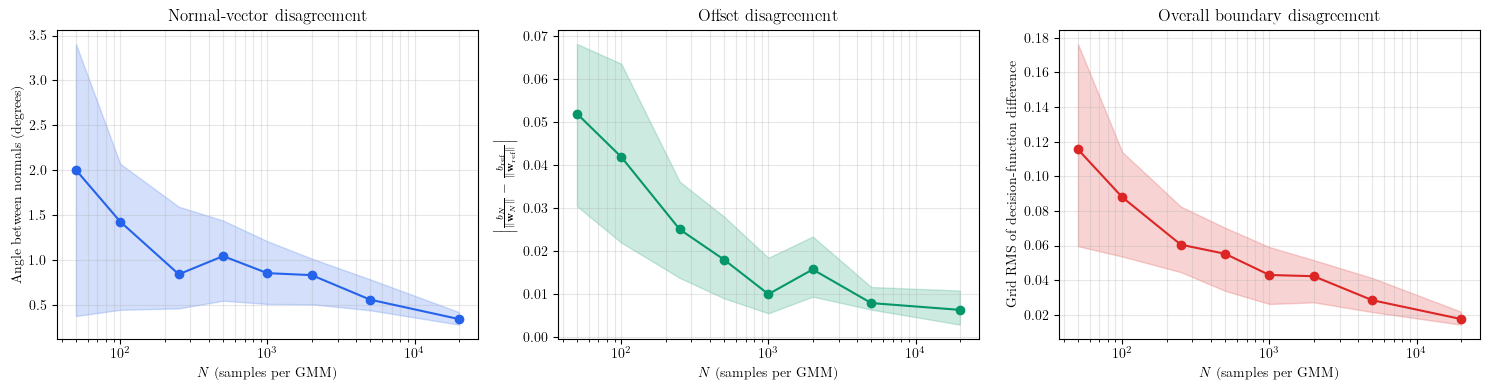

In [8]:
# Median + inter-quartile band over 30 seeds (saved as em_convergence_metrics.pgf).
fig = C.make_convergence_metrics_figure(agg)
fig.savefig(C.GRAPHICS_DIR / "em_convergence_metrics.pgf", backend="pgf", bbox_inches="tight")
plt.show()

## 6. Boundaries at each N

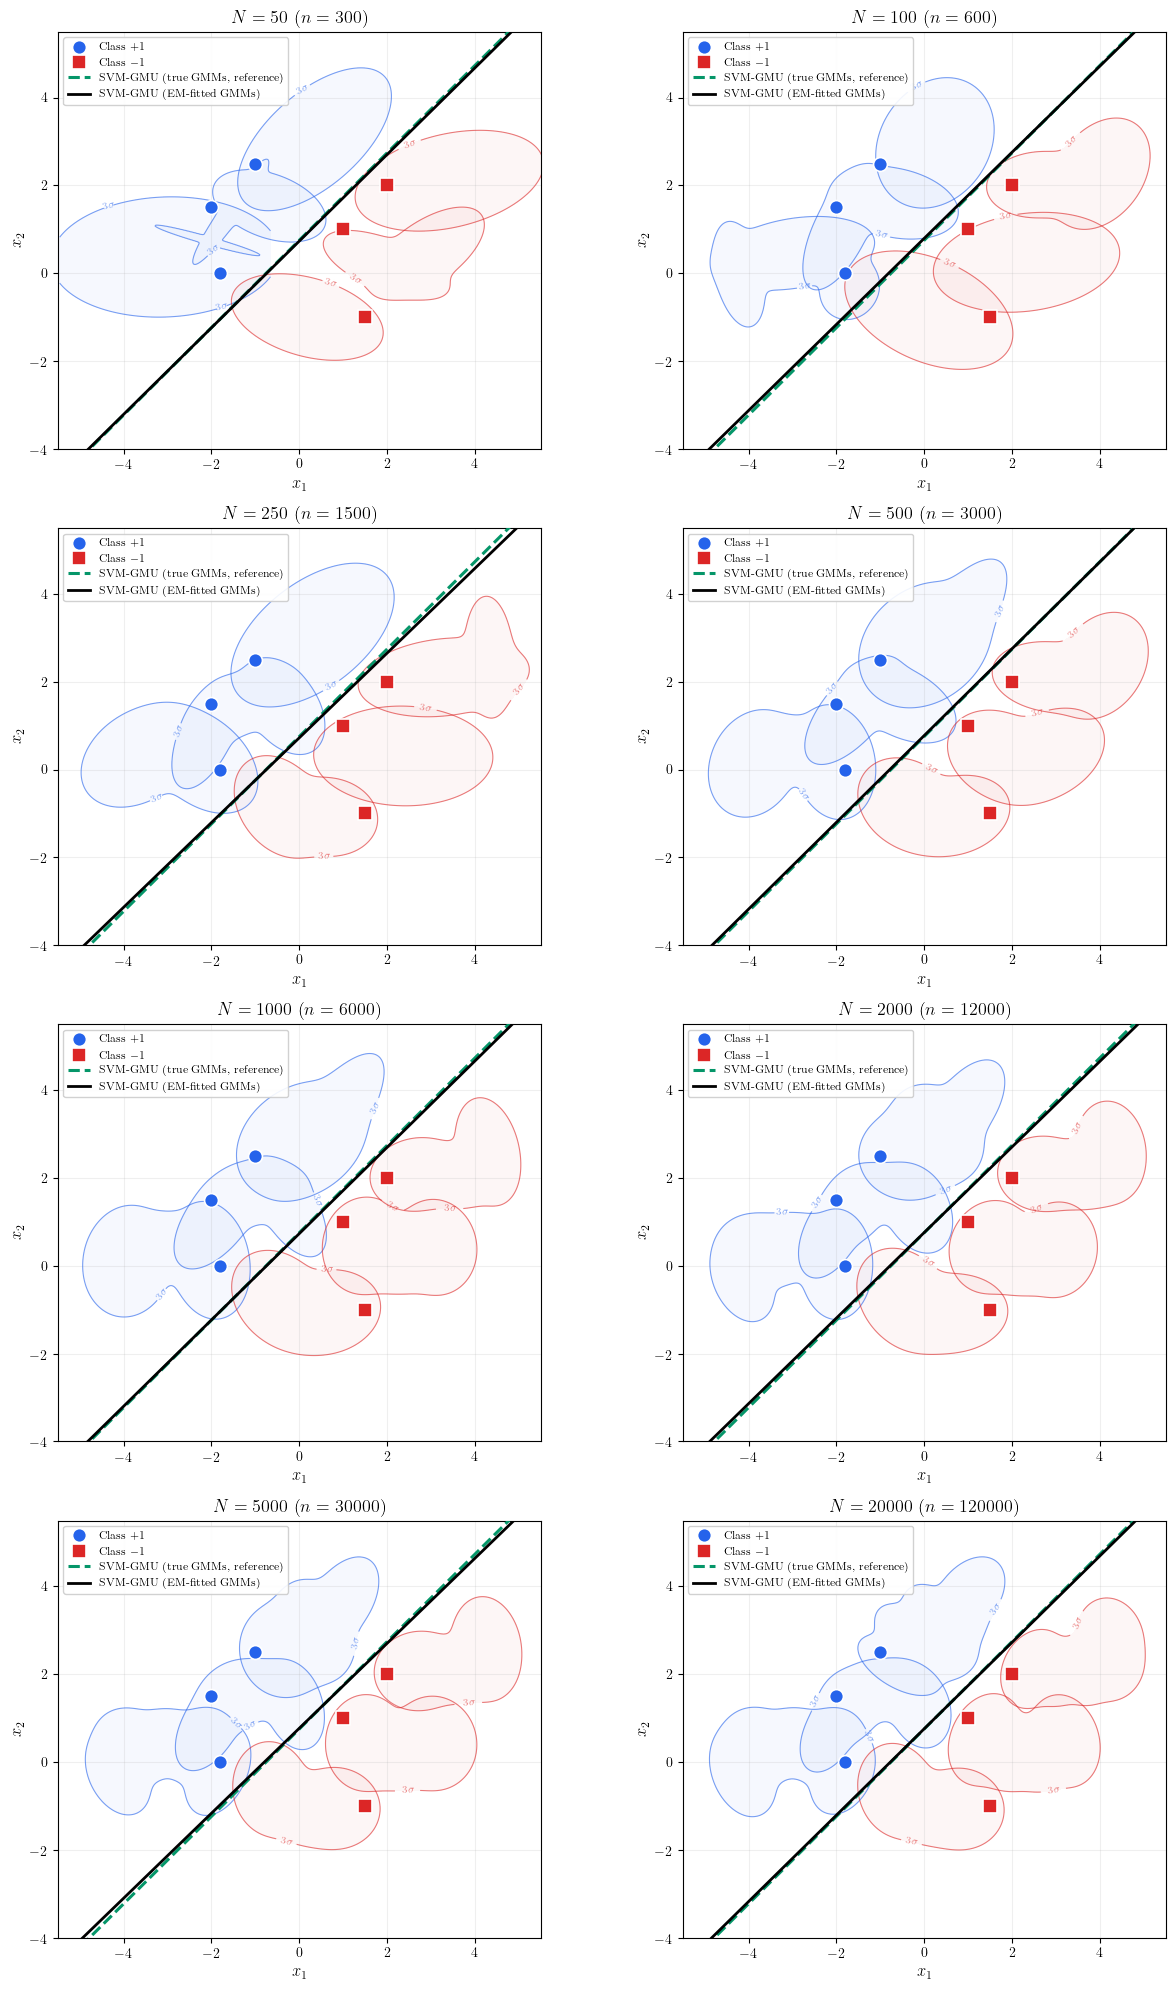

In [9]:
# Per-N EM-fitted contours with the reference and learned boundaries, for the
# representative seed 0 (saved as em_fitted_gmu_convergence.pgf).
fig = make_panel_figure(X, y, records, w_ref, b_ref)
fig.savefig(C.GRAPHICS_DIR / "em_fitted_gmu_convergence.pgf", backend="pgf", bbox_inches="tight")
plt.show()

## 7. Boundaries at each N over the sampled clouds

The same per-N panels as Section 6, but instead of the six observed points we overlay the sampled cloud that each EM fit was trained on (subsampled for readability). The contours are the EM-fitted (learned) GMMs, so they differ across panels and across the six clusters. As N grows, the cloud fills out the banana and crescent shapes, the learned mixtures sharpen toward them, and the EM-fitted SVM-GMU boundary (black) pulls onto the true-GMM reference (green).

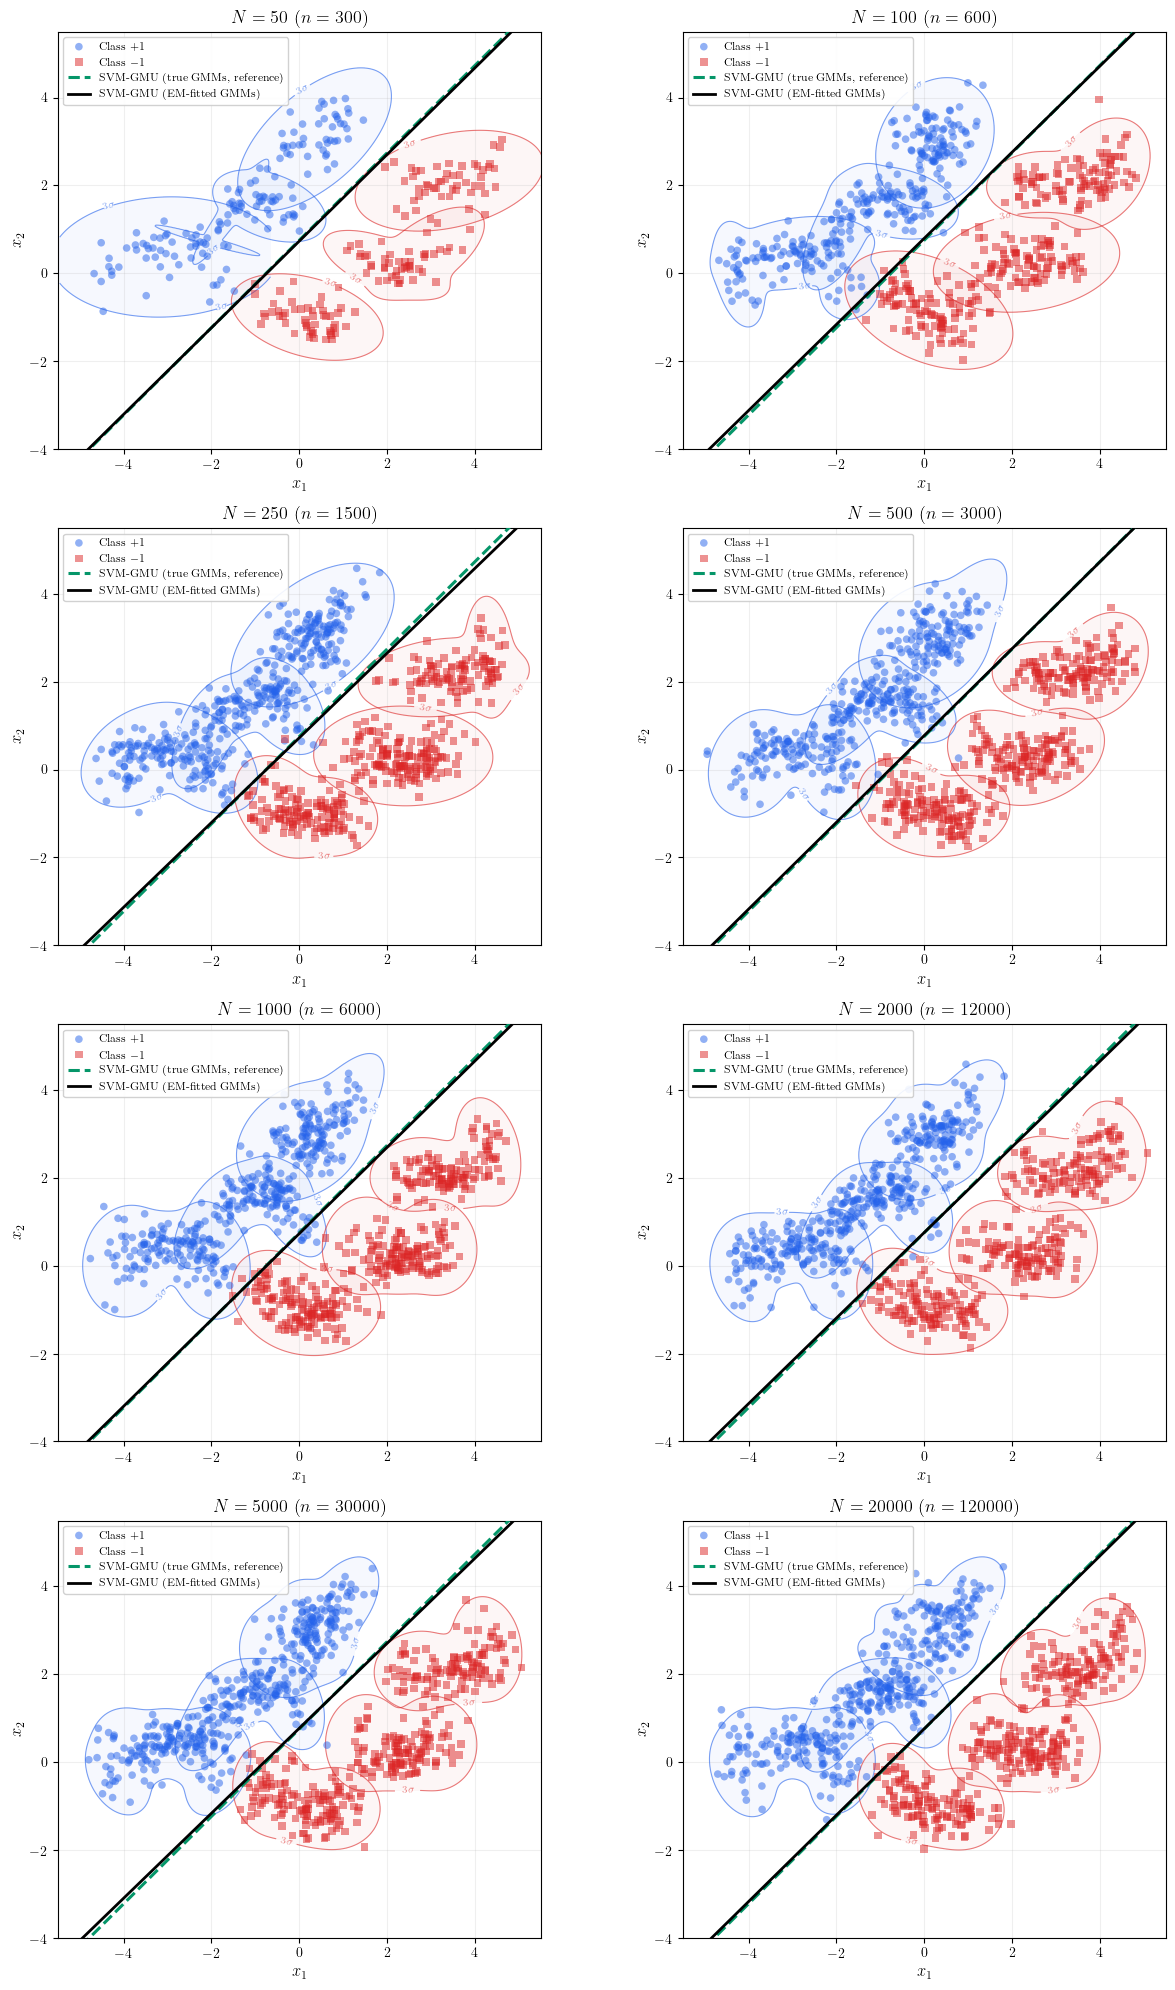

In [10]:
# Same per-N panels as above, but overlay the sampled cloud each EM fit was
# trained on instead of the six observed points. The contours are the EM-fitted
# (learned) GMMs for that N, so they differ across panels and across the six
# clusters; the observed points are not shown.
SCATTER_CAP = 800
scatter_rng = np.random.default_rng(MASTER_SEED + 1)

n_rows, n_cols = 4, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 5.0 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

xlim, ylim = (-5.5, 5.5), (-4.0, 5.5)
ref_color, learned_color = "#059669", "black"

for k, r in enumerate(records):
    ax = axes[k // n_cols, k % n_cols]

    # Layer 1: EM-fitted GMM contours for this N. plot_uncertainty also
    # scatters the six observed points; strip those PathCollections so only
    # the learned contours remain.
    plot_uncertainty(
        X, y, r["su_hat"], sigmas=(3,),
        title=rf"$N = {r['n']}$  $\left(n = {r['n_total']}\right)$",
        ax=ax,
    )
    for coll in list(ax.collections):
        if isinstance(coll, plt.matplotlib.collections.PathCollection):
            coll.remove()

    # Layer 2: the sampled cloud the EM fit was trained on (subsampled).
    X_exp, y_exp = r["X_exp"], r["y_exp"]
    if X_exp.shape[0] > SCATTER_CAP:
        idx = scatter_rng.choice(X_exp.shape[0], size=SCATTER_CAP, replace=False)
        X_plot, y_plot = X_exp[idx], y_exp[idx]
    else:
        X_plot, y_plot = X_exp, y_exp
    for label, color, marker, class_label in [
        (+1, "#2563eb", "o", "Class +1"),
        (-1, "#dc2626", "s", "Class −1"),
    ]:
        mask = y_plot == label
        ax.scatter(
            X_plot[mask, 0], X_plot[mask, 1],
            s=30, c=color, marker=marker,
            alpha=0.5, edgecolors="none", zorder=2,
            label=class_label,
        )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Layer 3: reference and EM-fitted SVM-GMU boundaries.
    _draw_line(ax, w_ref, b_ref, xlim, color=ref_color, linewidth=2.2,
               linestyle="--", zorder=4, label="SVM-GMU (true GMMs, reference)")
    _draw_line(ax, r["w"], r["b"], xlim, color=learned_color, linewidth=2.0,
               linestyle="-", zorder=5, label="SVM-GMU (EM-fitted GMMs)")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    handles, labels = ax.get_legend_handles_labels()
    keep = {"Class +1", "Class −1",
            "SVM-GMU (true GMMs, reference)", "SVM-GMU (EM-fitted GMMs)"}
    seen, uniq = set(), []
    for h, l in zip(handles, labels):
        if l in keep and l not in seen:
            seen.add(l)
            uniq.append((h, l))
    ax.legend([h for h, _ in uniq], [l for _, l in uniq],
              loc="upper left", fontsize=8, framealpha=0.9)

for k in range(len(records), n_rows * n_cols):
    axes[k // n_cols, k % n_cols].axis("off")
fig.tight_layout()
plt.show()

## 8. Interpretation

As N grows, the BIC-selected component counts climb from mostly one toward the true five or six, the EM-fitted contours sharpen into the true banana and crescent shapes, and the learned boundary (black) pulls onto the reference (green). The offset and angle metrics fall steadily toward zero. SVM-GMU therefore degrades gracefully when the mixtures are estimated rather than given: collect repeated noisy measurements, fit a GMM per example, and feed those to SVM-GMU.